# 07. Variational Autoencoders

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2025-11-25">25 Nov 2025</time> /
  <time datetime="2026-01-18">12 Mar 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/08_vae.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following sources were consulted in preparing this material:
    <ul style="margin-top: 0;">
      <li>
        Kingma, D. P., &amp; Welling, M. (2019).
        <a href="https://arxiv.org/abs/1906.02691">
          An Introduction to Variational Autoencoders</a>. <i>Foundations and Trends in Machine Learning</i>, 12(4), 307–392.
      </li>
      <li>
        Kingma, D. P., &amp; Welling, M. (2014).
        <a href="https://arxiv.org/abs/1312.6114">
          Auto-Encoding Variational Bayes</a>. arXiv:1312.6114.
      </li>
    </ul>
  </p>
</div>

[Generative modeling](https://en.wikipedia.org/wiki/Generative_model) studies how to learn a probability distribution that can produce data resembling the observations we see in the real world. Suppose we observe samples $x$ drawn from some unknown data distribution $p^*(x)$. The goal of generative modeling is to learn a model $p_\theta(x)$ that approximates this distribution well enough that we can generate new samples $x \sim p_\theta(x)$ which look similar to real data.

[Variational Autoencoders (VAEs)](https://en.wikipedia.org/wiki/Variational_autoencoder) combine [probabilistic modeling](../../mathematics/05_prob_modeling) with neural networks to learn how complex data are generated. The main idea is that observable data $x$ arise from simpler hidden variables $z$ through a generative process. By learning this process, the model can both explain the structure of the data and generate new samples that resemble the training distribution.

Classical [autoencoders](https://en.wikipedia.org/wiki/Autoencoder) are neural networks designed to learn compressed representations of data. They consist of two parts: an <em>encoder</em> that maps the input $x$ to a lower-dimensional representation $z$, and a <em>decoder</em> that reconstructs the input from this representation. Training typically minimizes a reconstruction loss such as $\|x-\hat{x}\|$, encouraging the network to learn a compact latent representation that preserves the essential structure of the data.

<figure>
  <img src="../../assets/images/vae/vae_architecture.png" alt="VAE Architecture" style="max-width: 80%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    <p>VAE architecture ~ <a href="//commons.wikimedia.org/wiki/User:EugenioTL" title="User:EugenioTL">EugenioTL</a> - <span class="int-own-work" lang="en">Own work</span>, <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>, <a href="https://commons.wikimedia.org/w/index.php?curid=107231101">Link</a></p>
  </figcaption>
</figure>

Unlike classical autoencoders, VAEs treat the latent representation probabilistically by modeling a distribution $q_\phi(z \mid x)$ rather than a single deterministic vector. This allows the latent space to be smooth and continuous, enabling sampling, interpolation between points, and generative modeling.

## Decoder Network

<div class="admonition quote">
  <p class="admonition-title">Quote</p>
  <p style="margin: 1em 0;">
    But the latent process of which we speak, is far from being obvious to men's minds, beset as they now are. For we mean not the measures, symptoms, or degrees of any process which can be exhibited in the bodies themselves, but simply a continued process, which, for the most part, escapes the observation of the senses. ~ <em>Francis Bacon (<a href='https://en.wikipedia.org/wiki/Novum_Organum'>Novum Organum</a>)</em>
  </p>
</div>

Assume we are given data drawn [independently and identically distributed (i.i.d.)](../../mathematics/03_probability/#independent-and-identically-distributed) from some unknown distribution $p^*(x)$. The goal of generative modeling is to learn a distribution $p_\theta(x)$ with parameters $\theta$ that approximates this data distribution. We can use a neural network for this purpose.

We could try to model the data distribution directly as $p_\theta(x)$. However, the observed variable $x$ usually lives in a very high-dimensional space. For example, an [MNIST image](../03_cnn_torch) has $x \in \mathbb{R}^{784}$, and natural images have far higher dimensionality. The distribution of such data can be extremely complex, with many modes, nonlinear dependencies, and structured variations. Learning $p_\theta(x)$ directly in pixel space therefore becomes very difficult.

<div class="admonition example">
  <p class="admonition-title">Example</p>
  <p style="margin: 1em 0;">
    An MNIST digit has size $28 \times 28$, so $x \in \mathbb{R}^{784}$. If pixels were binary, the number of possible images would be $2^{784} \approx 10^{236}$, an astronomically large space. A modest color image of size $256 \times 256 \times 3$ already lies in $\mathbb{R}^{196{,}608}$.
  </p>
</div>

[Latent variable models](../../mathematics/05_prob_modeling/#latent-variable-models) address this by assuming that each observation $x$ is generated from a simpler hidden cause $z$. Instead of modeling the complex distribution $p_\theta(x)$ directly, we model a conditional generation process $p_\theta(x \mid z)$ together with a simple prior $p(z)$.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    The purpose of $z$ is to capture underlying <a href='https://shahaliyev.org/writings/intro-deep-learning#factors-of-variation'>factors of variation</a> that are not directly observed but explain the data. In handwritten digits, these factors may include digit identity, stroke thickness, size, or writing style.
  </p>
</div>

Let's say our [latent variable](https://en.wikipedia.org/wiki/Latent_and_observable_variables) $z$ is sampled from a multivariate [Gaussian distribution](../../mathematics/03_probability/#normal-gaussian): $z \sim \mathcal{N}(\mu,\; \mathrm{diag}(\sigma^2))$. For example, drawing each variable from a normal distribution $\mathcal{N}(0, 1)$ may look like: $z = [-1.2,\; 0.4,\; 2.1,\; -0.7,\; \dots]$. We can pass an $L$-dimensional input $z$ to our neural network (decoder) with parameters $\theta$. The decoder should produce a conditional distribution $p_\theta(x \mid z)$, which indicates how likely an output $x$ is for a given latent $z$. By adjusting $\theta$, we want this conditional distribution to produce samples whose overall distribution approximates the true data distribution $p^\ast(x)$, which is basically the unknown underlying distribution of the universe the data lives in. In other words, when $z$ is drawn from some latent distribution, the resulting samples $x \sim p_\theta(x \mid z)$ should resemble real observable data. Hence, for the MNIST dataset, where each data point is a $28 \times 28$ grayscale image, the decoder should generate $784$ probabilities (one for each pixel):

$$
p_\theta(x = 1 \mid z) = (p_1, p_2, \dots, p_{784}).
$$
Here, each $p_j \in [0,1]$ is the model's predicted probability that pixel $j$ is "on". Since each pixel can be treated as a binary random variable, a natural probabilistic choice is to model pixel $j$ with a [Bernoulli distribution](https://www.acsu.buffalo.edu/~adamcunn/probability/bernoulli.html) parameterized by $p_j$. Under the i.i.d. assumption, the conditional [likelihood](https://en.wikipedia.org/wiki/Likelihood_function) of the image $x$ given $z$, also denoted by $p_\theta(x \mid z)$ (now a scalar), becomes

$$
p_\theta(x \mid z) = \prod_{j=1}^{784} \text{Bernoulli}(x_j \mid p_j).
$$

Here, $x_j$ is the observed pixel value in the data. This expression tells us how likely a particular image $x$ is, given a latent vector $z$.

<div class="admonition example">
  <p class="admonition-title">Example</p>
  <p style="margin: 1em 0;">
    Consider a very small $2 \times 2$ binary image and the decoder's predicted pixel probabilities:
    $$
    x =
    \begin{bmatrix}
    1 & 1 \\
    0 & 0
    \end{bmatrix},
    \qquad
    p =
    \begin{bmatrix}
    0.9 & 0.8 \\
    0.2 & 0.1
    \end{bmatrix}.
    $$
    Under the Bernoulli model and conditional independence assumption, the likelihood of the image is:
    <div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
    $$
    p_\theta(x \mid z)
    = 0.9 \times 0.8 \times (1-0.2) \times (1-0.1)
    = 0.5184
    $$.
    </div>
    The likelihood is relatively high because the model assigns high probabilities to pixels that are on (top row) and low probabilities to pixels that are off (bottom row). For a mismatched observation $\small
  x =
  \begin{bmatrix}
  0 & 0 \\
  1 & 1
  \end{bmatrix}$ the likelihood drops dramatically because the predicted probabilities disagree with the observed pixels:
  
  <div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
    $$
    (1-0.9) \times (1-0.8) \times 0.2 \times 0.1
    = 0.0004.
    $$
  </div>
  During training, the model adjusts its parameters so that images similar to the data receive higher likelihood.
  </p>
</div>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
class Decoder(nn.Module):
  def __init__(self, latent_dim, out_dim=784):
    super().__init__()
    self.fc1 = nn.Linear(latent_dim, 512)
    self.fc2 = nn.Linear(512, out_dim)

  def forward(self, z):
    z = z.view(z.size(0), -1)
    logits = self.fc2(F.relu(self.fc1(z)))
    return F.sigmoid(logits)

In [3]:
LATENT_DIM = 20
BATCH_SIZE = 32

As mentioned above, we need to sample $z$ from a multivariate normal distribution, where $\mu \in [-\infty, \infty]$ and $\sigma^2 \geq 0$. For now, we will use `torch.randn()` function to simulate random generation. Exponential function `torch.exp()` will be needed for mapping infinite range to be non-negative for variance.

In [4]:
mean    = torch.randn(BATCH_SIZE, LATENT_DIM)
logvar  = torch.randn(BATCH_SIZE, LATENT_DIM)
var     = torch.exp(logvar) # var >= 0

In practice, we will learn suitable values for mean and variance. We can now sample $z \sim \mathcal{N}(\mu,\; \mathrm{diag}(\sigma^2))$. Note that `torch.normal()` function accepts $\sigma$ instead of $\sigma^2$.

In [5]:
z = torch.normal(mean, torch.sqrt(var))
dec = Decoder(LATENT_DIM)
p_x_given_z = dec.forward(z)

Plotting the generated distribution $p_\theta(x \mid z)$ above will naturally produce noise, as the decoder parameters are random. We need to figure out a way to train our network for optimal parameters.

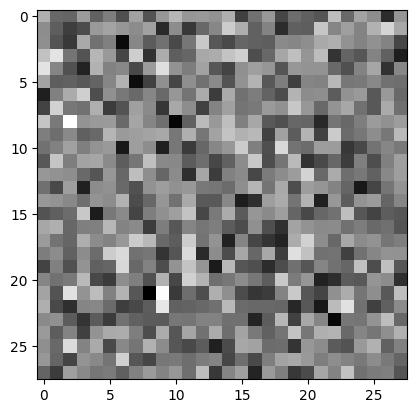

In [6]:
plt.imshow(p_x_given_z[0].detach().numpy().reshape(28,28), cmap='gray');

## Intractable Integral

As we have already introduced the latent variable $z$ to our probabilistic model, our objective is to learn the joint distribution $p(x, z)$, which has a well-known formula:

$$
p_\theta(x, z) = p_\theta(x \mid z)\, p(z).
$$

Both terms on the right are **tractable**. The decoder will produce the conditional likelihood $p_\theta(x \mid z)$ via a forward pass. The _prior_ $p(z)$ we can choose to be a simple Gaussian, which has a _closed-form_ density function we can easily compute. The difficulty appears only when we try to compute the _marginal likelihood (evidence)_ of an observed image $x$, which is our approximation of $p^\ast(x)$, given by another well-known formula:

$$
p_\theta(x) = \int p_\theta(x, z)\, dz.
$$

For a continuous high-dimensional latent vector, evaluating the integral above is computationally impossible because the integral does not have a closed-form solution. Integration would require evaluating the decoder network at every point in an $L$-dimensional space, which is intractable.

<div class="admonition example">
  <p class="admonition-title">Example</p>
  <p style="margin: 1em 0;">
    Suppose a simple example of a $1$-dimensional latent variable, where $z \in \mathbb{R}$ is a single real number. Even in this 1D case, computing the integral exactly requires evaluating the network $p_\theta(x \mid z)$ at every possible real value of $z$ from $ -\infty$ to $ +\infty$. Even if each dimension were sampled at only $100$ points, this would require $100^{20}$ evaluations for a $20$-dimensional latent, which is a number larger than the number of atoms in the universe.
  </p>
</div>

If we could somehow calculate this integral exactly, training the model would be straightforward. For each data point, we would compute log-likelihood $\log p_\theta(x)$ and optimize it with respect to $\theta$ using ordinary gradient descent. Alas, the integral is intractable.

## Encoder Network

Let's introduce the _posterior_ distribution $p_\theta(z \mid x)$ to our probabilistic model. This distribution tells us how likely each latent vector
$z$ is after we observe a particular data point $x$. We can define the posterior through [Bayes' rule](../../mathematics/03_probability/#bayes-rule):

$$
p_\theta(z \mid x) = \frac{p_\theta(x \mid z)\, p(z)}{p_\theta(x)} = \frac{p_\theta(x, z)}{\int p_\theta(x, z)\, dz}.
$$

However, the posterior is also intractable, as the denominator is intractable. To tackle this problem, the authors of the VAE paper introduce the _encoder (recognition) model_, which aims to optimize variational parameters $\phi$ so that the approximate posterior $q_\phi(z \mid x)$ is as close as possible to the intractable true posterior $p_\theta(z \mid x)$.

In simple terms, the encoder is a neural network with learnable parameters $\phi$ that outputs an approximate mean and variance of the required normal distribution for each input $x$. Instead of sampling $z$ randomly out of the blue, we sample the latent variable from the learned distribution $q_\phi(z \mid x)$, which depends on the input data.

In [7]:
class Encoder(nn.Module):
  def __init__(self, latent_dim, out_dim=128):
    super().__init__()
    self.conv1   = nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=1)
    self.conv2   = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=1)
    self.fc1     = nn.Linear(32 * 5 * 5, out_dim)
    self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.mean    = nn.Linear(out_dim, latent_dim)
    self.logvar  = nn.Linear(out_dim, latent_dim)

  def forward(self, x):
    out1 = self.maxpool(F.relu(self.conv1(x)))
    out2 = self.maxpool(F.relu(self.conv2(out1)))
    out2 = out2.view(out2.size(0), -1)
    out3 = F.relu(self.fc1(out2))
    mean = self.mean(out3)
    logvar = self.logvar(out3)
    return mean, logvar

Once we have our encoder, we can sample the latent variable $z$ conditioned on the input data. We will now load the MNIST dataset and demonstrate the process for a single batch of data.

In [8]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2
BATCH_SIZE = 64
LATENT_DIM = 30

In [9]:
from torchvision import datasets, transforms

train_data   = datasets.MNIST('root',train=True,transform=transforms.ToTensor(),download=True)
train_loader = torch.utils.data.DataLoader(train_data,shuffle=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


In [10]:
enc = Encoder(LATENT_DIM).to(DEVICE)
dec = Decoder(LATENT_DIM).to(DEVICE)

In [11]:
imgs, _ = next(iter(train_loader))
imgs = imgs.to(DEVICE)

mean, logvar = enc.forward(imgs)
var = torch.exp(logvar)

q_z_given_x = torch.normal(mean, torch.sqrt(var))
p_x_given_z = dec.forward(q_z_given_x)

In [12]:
LL = -F.binary_cross_entropy(p_x_given_z, imgs.view(imgs.size(0), -1), reduction='sum')
f'Log-likelihood: {LL.item():.4f}'

'Log-likelihood: -35096.5156'

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
  
  Note that the MNIST pixel intensities are continuous values in $[0,1]$, not binary values $0$ and $1$. We can still use a Bernoulli likelihood for each pixel because the Bernoulli log-likelihood is exactly the same expression used in binary <a href='../../mathematics/04_information'>cross-entropy</a>. Thus,

$$
p_\theta(x \mid z) = \prod_{j=1}^{784} p_j^{\,x_j} (1 - p_j)^{\,1 - x_j},
$$

and

$$
\log p_\theta(x \mid z) = \sum_{j=1}^{784} x_j \log p_j + (1 - x_j) \log (1 - p_j)
$$

remain valid even when the observed pixel values $x_j$ are real numbers in
$[0,1]$. Treating $x_j$ as a fractional target simply corresponds to using
binary cross-entropy, which is well-defined for any $x_j \in [0,1]$.
  </p>
</div>

The generated output will naturally again be noise, as neither encoder nor decoder parameters ($\phi$ and $\theta$) are optimal. The goal of VAE is to efficiently learn those parameters and maximize the likelihood.

## Evidence Lower Bound (ELBO)

Recall that we couldn't maximize the marginal likelihood $\log p_\theta(x)$ due to intractability. It turns out, with a nice trick up our sleeves, we can rewrite the marginal likelihood as expectation. The trick is that integrating any probability density over its entire domain is equal to $1$.

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
p_\theta(x) = p_\theta(x)\int q_\phi(z \mid x)\,dz  = \mathbb{E}_{q_\phi(z \mid x)}[\,p_\theta(x)\,].
$$
</div>

Our likelihood function $p_\theta(x)$ above returns a constant for each observed data point which does not depend on $z$. A constant function means that every possible value of the variable, no matter its probability, produces exactly the same output, so the weighted average (expectation) cannot change that value. Once we rewrite our likelihood as expectation, we can now make use of our variational posterior and Bayes rule to reach the following equation for log-likelihood:

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
\begin{aligned}
\log p_\theta(x)
&= \mathbb{E}_{q_\phi(z \mid x)}[\, \log p_\theta(x)\,] \\
&= \mathbb{E}_{q_\phi(z \mid x)}\!\left[\, \log
\left[
\frac{p_\theta(x,z)}{p_\theta(z \mid x)}
\right]\right] \\
&= \mathbb{E}_{q_\phi(z \mid x)}\!\left[\,
\log \left[\frac{p_\theta(x,z)}{q_\phi(z \mid x)}
\cdot
\frac{q_\phi(z \mid x)}{p_\theta(z \mid x)}\right]
\right] \\
&= \mathbb{E}_{q_\phi(z \mid x)}\!\left[\log \frac{p_\theta(x,z)}{q_\phi(z \mid x)}\right]
+ \mathbb{E}_{q_\phi(z \mid x)}\!\left[\log \frac{q_\phi(z \mid x)}{p_\theta(z \mid x)}\right].
\end{aligned}
$$
</div>

Here, the equation on the right corresponds to the [Kullback-Leibler divergence](../../mathematics/04_information/#kullback-leibler-divergence) formula $\mathrm{KL}\!\left[q_\phi(z \mid x)\,\|\, p_\theta(z \mid x)\right]$ between variational and true posteriors. As KL divergence is positive or zero (zero, in case our encoder somehow generates the true posterior), and $p_\theta(z \mid x)$ is unknown, we can ignore the KL divergence and concentrate on the first equation, which we call [Evidence Lower Bound](https://yunfanj.com/blog/2021/01/11/ELBO.html) (ELBO). The left-hand side is a lower bound on the log-likelihood for the observed data:

$$\mathcal{L}_{\theta,\phi}(x) \leq \log p_\theta(x).$$

We can rewrite ELBO equation further:

$$
\begin{aligned}
\mathcal{L}_{\theta,\phi}(x)
&= \mathbb{E}_{q_\phi(z \mid x)}\!\left[\log \frac{p_\theta(x,z)}{q_\phi(z \mid x)}\right] \\
&= \mathbb{E}_{q_\phi(z \mid x)}
\big[\log p_\theta(x,z) - \log q_\phi(z \mid x)\big] \\
&= \mathbb{E}_{q_\phi(z \mid x)}
\big[\log p_\theta(x \mid z) + \log p_\theta(z) - \log q_\phi(z \mid x)\big] \\
&= \mathbb{E}_{q_\phi(z \mid x)}\big[\log p_\theta(x \mid z)\big]
- \mathrm{KL}\!\left(q_\phi(z \mid x)\,\|\, p_\theta(z)\right).
\end{aligned}
$$

It turns out that instead of [maximizing the log-likelihood](../../mathematics/05_prob_modeling/#maximum-likelihood-estimation) of the evidence (a single data point), which is intractable, we can maximize the ELBO — the lower bound on the evidence likelihood — which is fully tractable. We can evaluate the expression above and optimize the network for both $\phi$ and $\theta$ in a single backward pass.

## Unbiased Gradient Estimation

We should now calculate gradients but we have a problem again. A single data point ELBO gradient is intractable as the expected value of the likelihood requires computing integral over all possible latent variables. Luckily, we can find an [unbiased estimator](https://en.wikipedia.org/wiki/Bias_of_an_estimator) of the gradient w.r.t. $\theta$ with the help of [Monte Carlo sampling](https://en.wikipedia.org/wiki/Monte_Carlo_method).

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
\begin{aligned}
\nabla_{\theta} \mathcal{L}_{\theta,\phi}(x)
&= \nabla_{\theta}\, \mathbb{E}_{q_{\phi}(z \mid x)}
    \left[ \log p_{\theta}(x, z) - \log q_{\phi}(z \mid x) \right] \\
&= \mathbb{E}_{q_{\phi}(z \mid x)}
    \left[ \nabla_{\theta}\left( \log p_{\theta}(x, z) - \log q_{\phi}(z \mid x) \right) \right] \\
&\simeq \nabla_{\theta}\left( \log p_{\theta}(x, z) - \log q_{\phi}(z \mid x) \right) \\
&= \nabla_{\theta}\log p_{\theta}(x, z).
\end{aligned}
$$
</div>

Monte Carlo estimator allows us to draw a few samples from $q_{\phi}(z \mid x)$ and approximate the expectation by averaging the function values at those samples. This works because the average of randomly drawn samples converges to the true expectation as $K$ increases. Using this approximation inside the gradient gives

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
\nabla_{\theta}\, \mathbb{E}_{q_{\phi}(z \mid x)}[f(z)]
\approx
\frac{1}{K} \sum_{k=1}^{K} \nabla_{\theta} f\!\left(z^{(k)}\right),
\qquad
z^{(k)} \sim q_{\phi}(z \mid x).
$$
</div>

which is an unbiased estimate of the true gradient.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    During neural network training, a single sample already provides an unbiased Monte Carlo estimate, as averaging comes from the minibatch: if a batch contains $B$ data points, the stochastic gradient $\frac{1}{B} \sum_{i=1}^{B} \nabla f\!\left(z^{(1)}_i\right)$ acts as the Monte Carlo average. Hence, we can use $K = 1$ and rely on minibatches to reduce variance.
  </p>
</div>

## Reparametrization Trick

<figure>
  <img src="../../assets/images/vae/reparam.png" alt="Reparameterization Trick Illustration" style="max-width: 60%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    <p>
      Illustration of the reparameterization trick ~ <a href="//commons.wikimedia.org/wiki/User:EugenioTL" title="User:EugenioTL">EugenioTL</a> - <span class="int-own-work" lang="en">Own work</span>, <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>, <a href="https://commons.wikimedia.org/w/index.php?curid=107231103">Link</a>
    </p>
  </figcaption>
</figure>

Estimating gradients w.r.t variational parameters $\phi$ is more complicated. The parameter $\phi$ appears inside the distribution $q_{\phi}(z \mid x)$, which means that when we take a gradient of the ELBO, we must also differentiate through the sampling operation itself:

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
\begin{aligned}
\nabla_{\phi} \mathcal{L}_{\theta,\phi}(x)
&=
\nabla_{\phi}\, \mathbb{E}_{q_{\phi}(z \mid x)}
\left[
\log p_{\theta}(x, z) - \log q_{\phi}(z \mid x)
\right]. \\
&\neq \mathbb{E}_{q_{\phi}(z \mid x)}
\left[\nabla_{\phi}\,
(\log p_{\theta}(x, z) - \log q_{\phi}(z \mid x)
\right)].
\end{aligned}
$$
</div>

To obtain a usable gradient estimator, the authors of the VAE paper introduce a simple yet efficient approach, rewriting the sampling process in a differentiable form. Instead of sampling $z$ directly from $q_{\phi}(z \mid x)$, we introduce a noise variable $\epsilon$ that does not depend on $\phi$:

$$
z = \mu_{\phi}(x) + \sigma_{\phi}(x)\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0, I).
$$

This is the [reparameterization trick](https://en.wikipedia.org/wiki/Reparameterization_trick). Now the randomness comes only from $\epsilon$, while $z$ becomes a deterministic and differentiable function of $\phi$. Using this transformation, the expectation can be rewritten as

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
\mathbb{E}_{q_{\phi}(z \mid x)}[f(z)]
=
\mathbb{E}_{\epsilon \sim \mathcal{N}(0,I)}
\left[
f\!\left(\mu_{\phi}(x) + \sigma_{\phi}(x)\epsilon\right)
\right],
$$
</div>

allowing gradients to pass through $z$ via standard backpropagation. The resulting gradient becomes

<div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
$$
\begin{aligned}
\nabla_{\phi} \mathcal{L}_{\theta,\phi}(x)
&=
\mathbb{E}_{\epsilon \sim \mathcal{N}(0,I)}
\left[
\nabla_{\phi}
\left(
\log p_{\theta}(x, z)
-
\log q_{\phi}(z \mid x)
\right)
\right].
\end{aligned}
$$
</div>

where $z = \mu_{\phi}(x) + \sigma_{\phi}(x)\, \epsilon$ which provides a low-variance and unbiased estimator that makes VAE optimization possible. As a consequence, a single data point Monte Carlo estimator becomes

$$
\tilde{\mathcal{L}}_{\theta,\phi}(x)
=
\log p_{\theta}(x, z)
-
\log q_{\phi}(z \mid x).
$$

Applying reparametrization trick allows PyTorch smoothly use autograd engine when calculating gradients.

In [13]:
def reparam(mean, var):
  eps = torch.randn_like(mean)
  std = torch.sqrt(var)
  z = mean + std * eps
  return z


<figure>
  <img src="../../assets/images/vae/reparam_vae.png" alt="Reparameterization Trick VAE Architecture" style="max-width: 80%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    <p>
      VAE architecture after the reparameterization trick ~ <a href="//commons.wikimedia.org/wiki/User:EugenioTL" title="User:EugenioTL">EugenioTL</a> - <span class="int-own-work" lang="en">Own work</span>, <a href="https://creativecommons.org/licenses/by-sa/4.0" title="Creative Commons Attribution-Share Alike 4.0">CC BY-SA 4.0</a>, <a href="https://commons.wikimedia.org/w/index.php?curid=107231104">Link</a>
    </p>
  </figcaption>
</figure>

## Training Variational Autoencoder

We have now built almost all the tools required for the training logic of the VAE. As the derivation is complicated and distracting for the main text, the formula for the closed-form ELBO KL-divergence term is given after the demonstration below.

In [14]:
LR = 0.001
NUM_EPOCHS = 10

In [15]:
optimizer = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=LR)

In [16]:
dec.train()
for e in range(NUM_EPOCHS):
  loss = 0
  for X, _ in train_loader:
    X = X.to(DEVICE)
    optimizer.zero_grad()

    mean, logvar = enc.forward(X)
    var = torch.exp(logvar)

    q_z_given_x = reparam(mean, var)
    p_x_given_z = dec.forward(q_z_given_x)

    LL = -F.binary_cross_entropy(p_x_given_z, X.view(X.size(0), -1), reduction='sum')
    KL = 0.5 * torch.sum(mean**2 + var - 1 - logvar)
    ELBO = LL - KL
    batch_loss = -ELBO

    batch_loss.backward()
    optimizer.step()
    loss += batch_loss.item() / (BATCH_SIZE * 784)
  print(f"Epoch {e+1}/{NUM_EPOCHS}, Loss: {loss:.4f}")

Epoch 1/10, Loss: 193.2767
Epoch 2/10, Loss: 145.9898
Epoch 3/10, Loss: 136.3119
Epoch 4/10, Loss: 132.1799
Epoch 5/10, Loss: 130.1328
Epoch 6/10, Loss: 128.7921
Epoch 7/10, Loss: 127.8008
Epoch 8/10, Loss: 127.0921
Epoch 9/10, Loss: 126.4143
Epoch 10/10, Loss: 125.9678


After we train the VAE network, all we need to do is sample $z$ from a Gaussian prior and pass it to the decoder for generation. If we have done everything right, we may even see some MNIST-like numbers on the screen.

In [17]:
dec.eval()

with torch.no_grad():
  z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
  imgs = dec.forward(z)

imgs = imgs.detach().cpu().numpy()

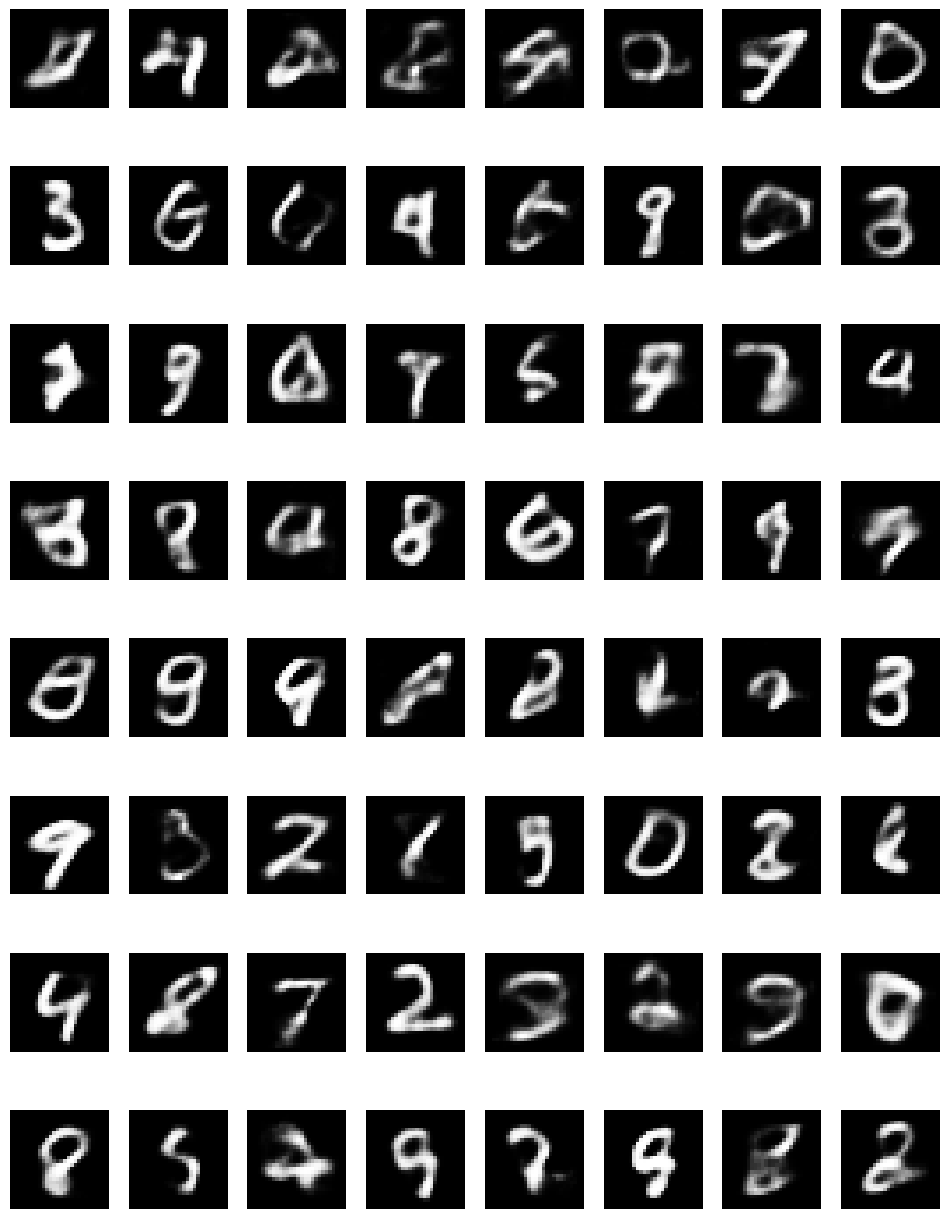

In [18]:
num_imgs = imgs.shape[0]
imgs_per_row = 8
num_rows = (num_imgs + imgs_per_row - 1) // imgs_per_row

plt.figure(figsize=(12, num_rows * 2))

for i in range(num_imgs):
    plt.subplot(num_rows, imgs_per_row, i + 1)
    plt.imshow(imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

<div class="admonition success">
  <p class="admonition-title">Exercise</p>
  <p style="margin: 1em 0;">
    Train a VAE model on the CIFAR-10 dataset.
  </p>
</div>

## Closed-Form Gaussian KL-divergence

We already know that $\log p_\theta(x \mid z)$ can be treated as a BCE loss. However, we still need to work out closed-form expressions for the right-hand side of the ELBO, which has the following log form:

<div style="overflow-x:auto; max-width:100%;">
    $$
    \mathrm{KL}\!\left(q_\phi(z \mid x)\,\|\,p(z)\right)
    =
    \mathbb{E}_{q_\phi(z\mid x)}
    \Big[
    \log q_\phi(z\mid x)
    -
    \log p(z)
    \Big].
    $$
</div>

Gaussian family is one of the few distributions where the KL-divergence has a simple analytic form. For example, in 1D, the approximate posterior distribution $q_\phi(z \mid x)$ and the prior can be sampled from $\mathcal{N}(\mu, \sigma^2)$ and $\mathcal{N}(0, 1)$ respectively. Knowing that the standard normal is a special case of the normal distribution, we have:

<div style="overflow-x:auto; max-width:100%;">
$$
\begin{aligned}
\log q_\phi(z \mid x)
&=
\log\!\left[
\frac{1}{\sqrt{2\pi\sigma^{2}}}
\exp\!\left(-\frac{(z-\mu)^{2}}{2\sigma^{2}}\right)
\right]
=
-\frac{1}{2}\log(2\pi\sigma^{2})
-
\frac{(z-\mu)^{2}}{2\sigma^{2}}.
\end{aligned}
$$
</div>

Therefore, subtracting the two Gaussians has the following form:

<div style="overflow-x:auto; max-width:100%;">
$$
\begin{aligned}
\log q_\phi(z \mid x) - \log p(z)
&=
\left[
-\frac{1}{2}\log(2\pi\sigma^{2})
-
\frac{(z-\mu)^{2}}{2\sigma^{2}}
\right]
-
\left[
-\frac{1}{2}\log(2\pi)
-
\frac{z^{2}}{2}
\right]
=
-\frac{1}{2}\log\sigma^{2}
-
\frac{(z-\mu)^{2}}{2\sigma^{2}}
+
\frac{z^{2}}{2}.
\end{aligned}
$$
</div>

Substituting these moments into the KL expression in its expectation form, we obtain:

<div style="overflow-x:auto; max-width:100%;">
$$
\begin{aligned}
\mathbb{E}_{q_\phi(z\mid x)}
\Big[
\log q_\phi(z\mid x)
-
\log p(z)
\Big]
&=
\mathbb{E}_{q_\phi(z \mid x)}
\Big[
-\tfrac{1}{2}\log\sigma^{2}
-
\tfrac{(z-\mu)^{2}}{2\sigma^{2}}
+
\tfrac{z^{2}}{2}
\Big]
=
-\tfrac{1}{2}\log\sigma^{2}
-
\tfrac{1}{2\sigma^{2}}
\mathbb{E}_{q_\phi(z \mid x)}[(z-\mu)^{2}]
+
\tfrac{1}{2}
\mathbb{E}_{q_\phi(z \mid x)}[z^{2}].
\end{aligned}
$$
</div>

which becomes, after substituting the known Gaussian moments $\sigma^{2}$ and $\mu^{2} + \sigma^{2}$:

<div style="overflow-x:auto; max-width:100%;">
$$
\begin{aligned}
\mathrm{KL}\!\left(q_\phi(z \mid x)\,\|\,p(z)\right)
&=
-\tfrac{1}{2}\log\sigma^{2}
-
\tfrac{1}{2}
+
\tfrac{1}{2}\mu^{2}
+
\tfrac{1}{2}\sigma^{2}
&=
\tfrac{1}{2}
\left(
\mu^{2}
+
\sigma^{2}
-
1
-
\log\sigma^{2}
\right).
\end{aligned}
$$
</div>

For an $L$-dimensional latent variable, we choose the approximate posterior to be a multivariate Gaussian with diagonal covariance:
$q_\phi(z \mid x)=\mathcal{N}\!\big(\mu, \mathrm{diag}(\sigma^2)\big),$
and the prior a standard multivariate normal:
$p(z) = \mathcal{N}(0, I).$ Because the covariance of $q_\phi(z \mid x)$ is diagonal, both $q_\phi(z \mid x)$ and $p(z)$ factorize over dimensions:

<div style="overflow-x:auto; max-width:100%;">
$$
q_\phi(z \mid x)
=
\prod_{j=1}^L q_{\phi,j}(z_j \mid x),
\qquad
p(z)
=
\prod_{j=1}^L p_j(z_j).
$$
</div>

From here, we can derive the final closed-form expression for the KL-divergence between the approximate posterior and the prior:

<div style="overflow-x:auto; max-width:100%;">
$$
\begin{aligned}
\mathrm{KL}\!\left(q_\phi(z \mid x)\,\|\,p(z)\right)
&=
\sum_{j=1}^L
\mathrm{KL}\!\left(q_{\phi,j}(z_j \mid x)\,\|\,p_j(z_j)\right)
=
\tfrac{1}{2}
\sum_{j=1}^L
\left(
\mu_j^{2}
+
\sigma_j^{2}
-
1
-
\log\sigma_j^{2}
\right).
\end{aligned}
$$
</div>

## Limitations

Despite their elegance, VAEs have several limitations. A common issue is that samples generated by VAEs often appear blurry, especially in image generation tasks. This occurs because the likelihood assumptions (such as pixel-wise Gaussian or Bernoulli models) and the ELBO objective encourage the model to average over many plausible reconstructions rather than committing to sharp details.

Another challenge is the trade-off between reconstruction quality and latent regularization. The KL-divergence term pushes the approximate posterior toward the prior, which can restrict how much information the latent variable $z$ carries about the data. In some cases this leads to **posterior collapse**, where the decoder ignores the latent variable entirely and the model behaves like a simple unconditional generator.

VAEs can also struggle to match the sample quality of more recent generative models such as GANs or diffusion models. While they provide a clear probabilistic framework and stable training, their samples may lack the high-frequency detail or realism achieved by these alternative approaches.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    Although VAEs are not typically used alone in modern image generators, they often play a certain role in them. For example, <a href='https://en.wikipedia.org/wiki/Stable_Diffusion'>stable diffusion</a> uses a VAE to encode images into a lower-dimensional latent space before the diffusion model operates on them. Running the generative process in this latent space significantly reduces computational cost while preserving the main visual structure of the images. The VAE decoder is then used to map the generated latent representation back to the pixel space.
  </p>
</div>

## Conclusion

<div class="admonition tip">
  <p class="admonition-title">Tip</p>
  <p style="margin: 1em 0;">
    Check out this <a href='
https://xnought.github.io/vae-explainer/'>VAE explainer</a> for general understanding and interpolation.
  </p>
</div>

By introducing latent variables, the variational autoencoder model assumes that complex observations arise from simpler hidden factors. Instead of directly modeling the high-dimensional data distribution $p_\theta(x)$, VAEs learn a generative process in which a latent variable $z$ is sampled from a simple prior and then mapped to the data space through a neural network decoder.

The main challenge of latent-variable models is that the marginal likelihood $p_\theta(x)$ and the true posterior $p_\theta(z \mid x)$ are typically intractable. VAEs introduce variational approximation $q_\phi(z \mid x)$ and optimization via ELBO. This transforms the problem into a tractable objective consisting of two terms: a reconstruction term that encourages accurate generation of the data and a KL-divergence term that regularizes the latent distribution toward the prior.

The nice _reparameterization trick_ makes optimization practical by rewriting the stochastic sampling process as a deterministic transformation of parameters and noise. This allows gradients to flow through the sampling step and enables efficient training using standard backpropagation. Once trained, a VAE can generate new samples by drawing latent variables from the prior and passing them through the decoder. Beyond generation, the learned latent space often captures meaningful structure in the data, supporting interpolation, representation learning, and downstream tasks.